# Time Window Correction Comparison

Comparing true cluster coordinates before and after time window correction
- Old time window: -200 to 1600 μs
- New time window: -205 to 1508.5 μs

In [35]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

In [36]:
old_file = '/exp/sbnd/data/users/prabhjot/wirecell_clustering/developcode/wcp-porting-validation/sbnd/TrueJobs/old/tru-apa0-0.json'
new_file = '/exp/sbnd/data/users/prabhjot/wirecell_clustering/developcode/wcp-porting-validation/sbnd/TrueJobs/new/tru-apa0-0.json'

print('Loading old time window data...')
with open(old_file, 'r') as f:
    old_data = json.load(f)

print('Loading new time window data...')
with open(new_file, 'r') as f:
    new_data = json.load(f)

old_df = pd.DataFrame({
    'x': old_data['x'],
    'y': old_data['y'],
    'z': old_data['z'],
    't': old_data['t'],
    'cluster_id': old_data['cluster_id']
})

new_df = pd.DataFrame({
    'x': new_data['x'],
    'y': new_data['y'],
    'z': new_data['z'],
    't': new_data['t'],
    'cluster_id': new_data['cluster_id']
})

print(f'Old data: {len(old_df):,} points, {old_df["cluster_id"].nunique()} clusters')
print(f'New data: {len(new_df):,} points, {new_df["cluster_id"].nunique()} clusters')

Loading old time window data...
Loading new time window data...
Old data: 36,349 points, 47 clusters
New data: 33,771 points, 47 clusters


## 1D Coordinate Distributions Comparison

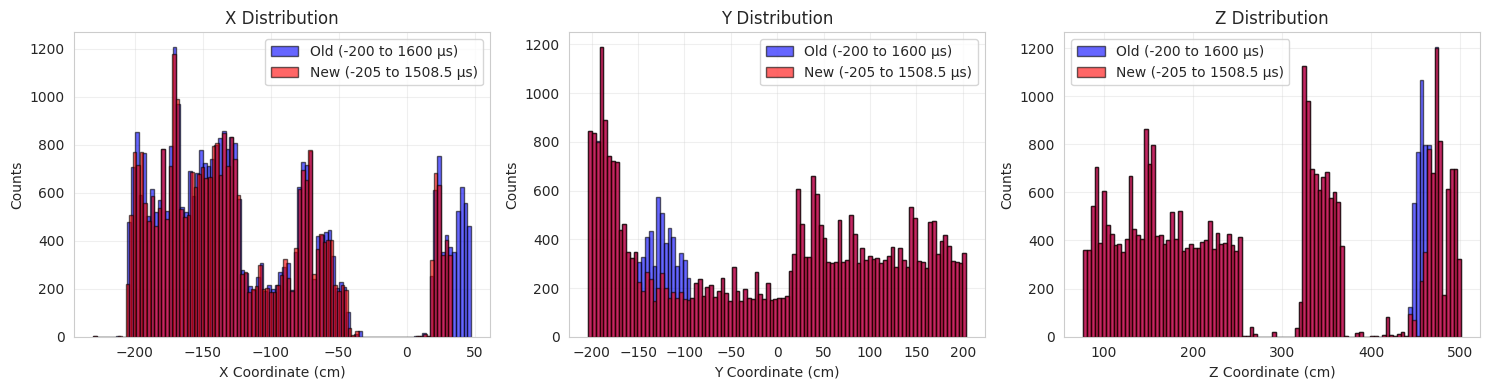


Coordinate Statistics:

Old Time Window:
                  x             y             z
count  36349.000000  36349.000000  36349.000000
mean    -111.577501    -16.454970    280.882286
std       72.679161    130.807914    137.650118
min     -230.300000   -203.700000     76.700000
25%     -168.700000   -145.200000    154.500000
50%     -133.700000     -3.900000    245.200000
75%      -71.600000     98.700000    447.000000
max       47.500000    203.700000    501.000000

New Time Window:
                  x             y             z
count  33771.000000  33771.000000  33771.000000
mean    -123.202419     -8.373344    267.655346
std       61.472892    132.213951    133.886820
min     -230.300000   -203.700000     76.700000
25%     -170.700000   -153.000000    149.900000
50%     -138.100000     20.600000    231.700000
75%      -79.300000    107.100000    356.800000
max       33.300000    203.700000    501.000000


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(old_df['x'], bins=100, alpha=0.6, label='Old (-200 to 1600 μs)', color='blue', edgecolor='black')
axes[0].hist(new_df['x'], bins=100, alpha=0.6, label='New (-205 to 1508.5 μs)', color='red', edgecolor='black')
axes[0].set_xlabel('X Coordinate (cm)')
axes[0].set_ylabel('Counts')
axes[0].set_title('X Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(old_df['y'], bins=100, alpha=0.6, label='Old (-200 to 1600 μs)', color='blue', edgecolor='black')
axes[1].hist(new_df['y'], bins=100, alpha=0.6, label='New (-205 to 1508.5 μs)', color='red', edgecolor='black')
axes[1].set_xlabel('Y Coordinate (cm)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Y Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(old_df['z'], bins=100, alpha=0.6, label='Old (-200 to 1600 μs)', color='blue', edgecolor='black')
axes[2].hist(new_df['z'], bins=100, alpha=0.6, label='New (-205 to 1508.5 μs)', color='red', edgecolor='black')
axes[2].set_xlabel('Z Coordinate (cm)')
axes[2].set_ylabel('Counts')
axes[2].set_title('Z Distribution')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('coordinate_distributions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCoordinate Statistics:')
print('\nOld Time Window:')
print(old_df[['x', 'y', 'z']].describe())
print('\nNew Time Window:')
print(new_df[['x', 'y', 'z']].describe())

## 3D Projections: Overlaid Old and New Clusters

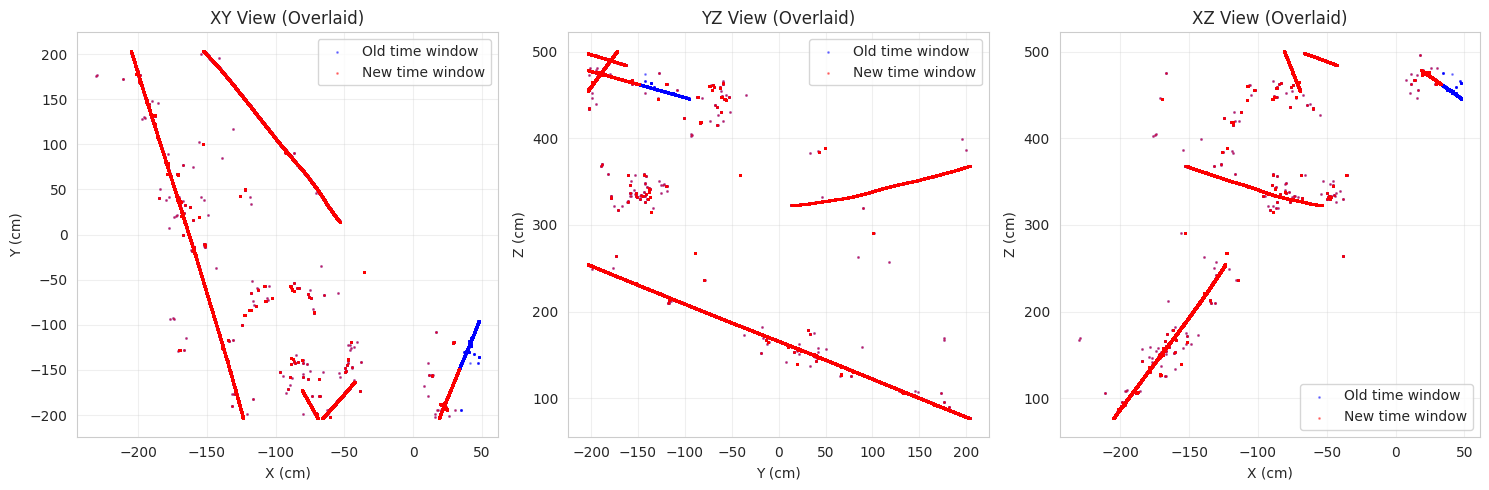

In [38]:
fig = plt.figure(figsize=(15, 5))
markersize = 1

ax1 = fig.add_subplot(131)
ax1.scatter(old_df['x'], old_df['y'], s=markersize, alpha=0.4, color='blue', label='Old time window')
ax1.scatter(new_df['x'], new_df['y'], s=markersize, alpha=0.4, color='red', label='New time window')
ax1.set_xlabel('X (cm)')
ax1.set_ylabel('Y (cm)')
ax1.set_title('XY View (Overlaid)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(132)
ax2.scatter(old_df['y'], old_df['z'], s=markersize, alpha=0.4, color='blue', label='Old time window')
ax2.scatter(new_df['y'], new_df['z'], s=markersize, alpha=0.4, color='red', label='New time window')
ax2.set_xlabel('Y (cm)')
ax2.set_ylabel('Z (cm)')
ax2.set_title('YZ View (Overlaid)')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(133)
ax3.scatter(old_df['x'], old_df['z'], s=markersize, alpha=0.4, color='blue', label='Old time window')
ax3.scatter(new_df['x'], new_df['z'], s=markersize, alpha=0.4, color='red', label='New time window')
ax3.set_xlabel('X (cm)')
ax3.set_ylabel('Z (cm)')
ax3.set_title('XZ View (Overlaid)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('projections_overlaid.png', dpi=150, bbox_inches='tight')
plt.show()

## Overlaid Cluster Pair Comparison (Before & After)

Comparing matching clusters from old and new time windows on the same axes.

Common clusters: 47
Cluster IDs: [10000001, 10000005, 10000007, 10000008, 10000011, 10000296, 10000399, 10000770, 10000782, 10000946]...


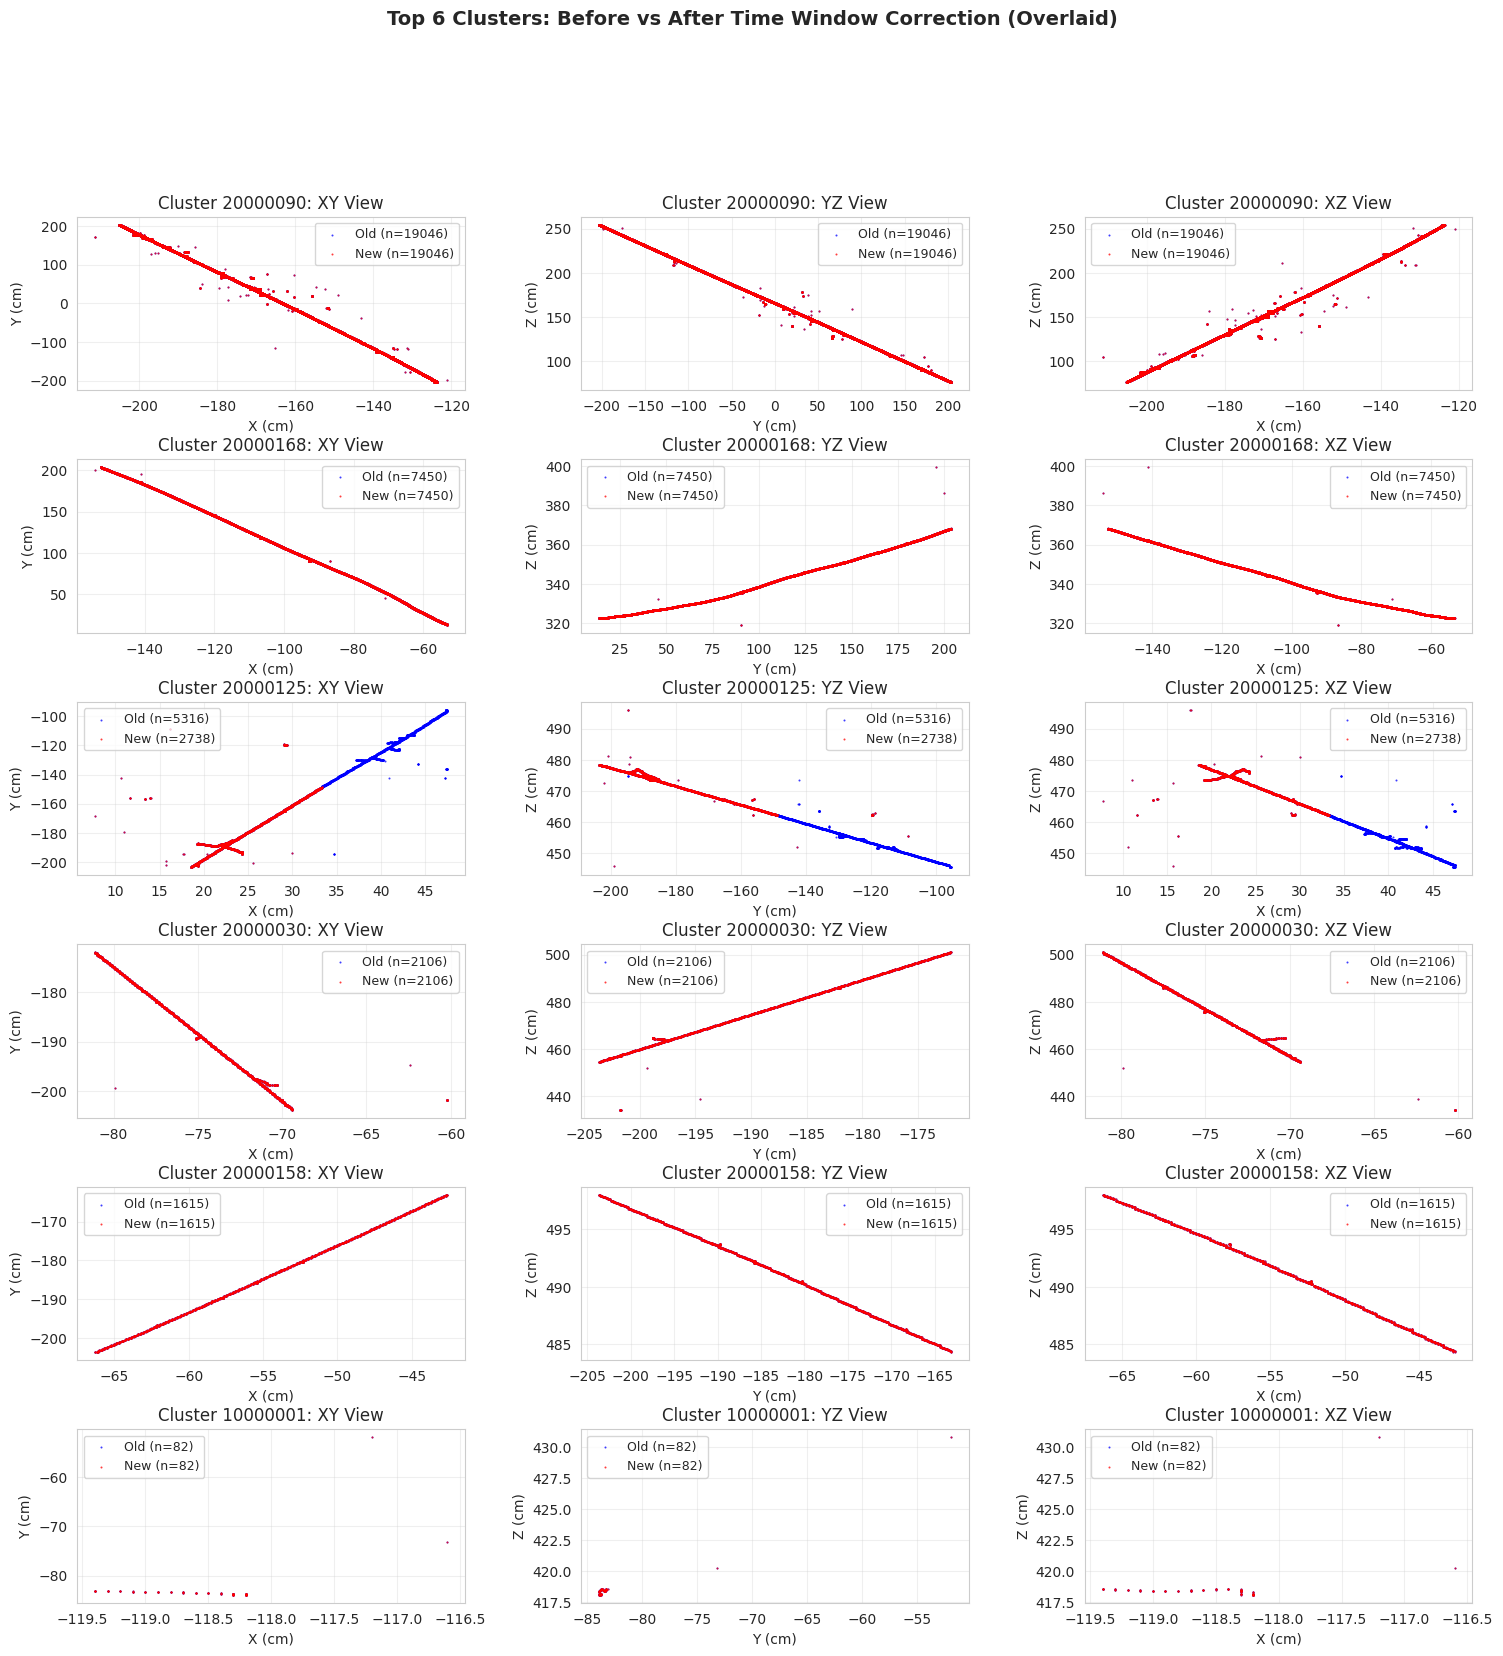


Plotted 6 matching cluster pairs with overlaid old and new points


In [ ]:
# Get common clusters (should be all since IDs match)
common_clusters = sorted(list(set(old_df['cluster_id'].unique()) & set(new_df['cluster_id'].unique())))

print(f'Common clusters: {len(common_clusters)}')
print(f'Cluster IDs: {common_clusters[:10]}...' if len(common_clusters) > 10 else f'Cluster IDs: {common_clusters}')

# Plot top 6 matching cluster pairs overlaid
top_clusters = old_cluster_sizes.head(6).index.tolist()

fig = plt.figure(figsize=(18, 18))
gs = GridSpec(6, 3, figure=fig, hspace=0.4, wspace=0.3)

for idx, cluster_id in enumerate(top_clusters):
    old_cluster = old_df[old_df['cluster_id'] == cluster_id]
    new_cluster = new_df[new_df['cluster_id'] == cluster_id]
    
    # XY view
    ax = fig.add_subplot(gs[idx, 0])
    ax.scatter(old_cluster['x'], old_cluster['y'], s=markersize, alpha=0.6, color='blue', label=f'Old (n={len(old_cluster)})', linewidth=0.5)
    ax.scatter(new_cluster['x'], new_cluster['y'], s=markersize, alpha=0.6, color='red', label=f'New (n={len(new_cluster)})', linewidth=0.5)
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')
    ax.set_title(f'Cluster {cluster_id}: XY View')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    
    # YZ view
    ax = fig.add_subplot(gs[idx, 1])
    ax.scatter(old_cluster['y'], old_cluster['z'], s=markersize, alpha=0.6, color='blue', label=f'Old (n={len(old_cluster)})', linewidth=0.5)
    ax.scatter(new_cluster['y'], new_cluster['z'], s=markersize, alpha=0.6, color='red', label=f'New (n={len(new_cluster)})', linewidth=0.5)
    ax.set_xlabel('Y (cm)')
    ax.set_ylabel('Z (cm)')
    ax.set_title(f'Cluster {cluster_id}: YZ View')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    
    # XZ view
    ax = fig.add_subplot(gs[idx, 2])
    ax.scatter(old_cluster['x'], old_cluster['z'], s=markersize, alpha=0.6, color='blue', label=f'Old (n={len(old_cluster)})', linewidth=0.5)
    ax.scatter(new_cluster['x'], new_cluster['z'], s=markersize, alpha=0.6, color='red', label=f'New (n={len(new_cluster)})', linewidth=0.5)
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Z (cm)')
    ax.set_title(f'Cluster {cluster_id}: XZ View')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Top 6 Clusters: Before vs After Time Window Correction (Overlaid)', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print(f'\nPlotted {len(top_clusters)} matching cluster pairs with overlaid old and new points')